In [1]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from tqdm import tqdm
import statsmodels.api as sm
from scipy import stats

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Subset Olink RVAT significant
LOCAL_DATA_DIR = "/home/dnanexus/data_dir/"

# olink_burden_test_file = "proteomics_prs_am_loftee_mac20_burden_regression_results.parquet"
# olink_burden_test_file = "proteomics_prs_loftee_mac20_burden_regression_results.parquet"
olink_burden_test_file = "proteomics_prs_df_loftee_mac20_burden_regression_results.parquet"
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/olink/blacklist/{olink_burden_test_file} -o {LOCAL_DATA_DIR}/{olink_burden_test_file}

olink_whitelist = (
    pl.read_parquet(f'{LOCAL_DATA_DIR}/{olink_burden_test_file}')
    .rename({'gene': 'region'})
    .filter((pl.col('padj')<=0.05) & (pl.col('wilcox_padj')<=0.05) )
    .select(['region'])
    .with_columns(
        phenotype = pl.col('region') + '_olink'
    )
)

olink_correlations_file = "olink_all_mac20_lofteeHC_correlations.parquet"
olink_correlations_file = "olink_LOFTEE_correlations_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/{olink_correlations_file} -o {LOCAL_DATA_DIR}/{olink_correlations_file}

olink_corrs = (
    pl.read_parquet(f'{LOCAL_DATA_DIR}/{olink_correlations_file}')
    .filter(pl.col('correlation')>0)
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .drop_nans()
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

olink_whitelist = (
    olink_whitelist
    .join(olink_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    # .sort('loftee_corr_abs', descending=True)
    # .sort('pval_fdr')
    # .unique(subset=["region"], keep="first", maintain_order=True)
)

olink_whitelist

Error: path "/home/dnanexus/data_dir//proteomics_prs_df_loftee_mac20_burden_re
gression_results.parquet" already exists but -f/--overwrite was not set
[===========================================================>] Completed 21,491 of 21,491 bytes (100%) /home/dnanexus/data_dir//olink_LOFTEE_correlations_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquett


region,phenotype,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64
"""ENSG00000116675""","""ENSG00000116675_olink""",0.022487,0.022487,1.0
"""ENSG00000123609""","""ENSG00000123609_olink""",0.076186,0.076186,1.0
"""ENSG00000167851""","""ENSG00000167851_olink""",0.066067,0.066067,1.0
"""ENSG00000156711""","""ENSG00000156711_olink""",0.04852,0.04852,1.0
"""ENSG00000174990""","""ENSG00000174990_olink""",0.010786,0.010786,1.0
…,…,…,…,…
"""ENSG00000136542""","""ENSG00000136542_olink""",0.040315,0.040315,1.0
"""ENSG00000196576""","""ENSG00000196576_olink""",0.082542,0.082542,1.0
"""ENSG00000111144""","""ENSG00000111144_olink""",0.088107,0.088107,1.0


In [3]:
# Configuration and paths
mac = 20
abs_phenotypes = False
keep_fillna = False

# Initialize new annotation variable as None
new_anno_local = None

# Load annotation configuration
if abs_phenotypes:
    config_path = "/home/dnanexus/ukbgym/config_odds.yaml" # If abs_pheno then deleteriousness direction
else:    
    config_path = "/home/dnanexus/ukbgym/config_olink_odds.yaml"

with open(config_path) as f:
    config = yaml.safe_load(f)

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#DD4344""","""LOFTEE HC""",1
"""genetic_diversity""","""cadd_raw""","""chocolate""","""CADD Raw""",1
"""missense""","""am_pathogenicity""","""#FFCA28""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#FB8C00""","""ESM1v""",-1
"""missense""","""score_pai3d""","""#D84315""","""PrimateAI-3D""",1
…,…,…,…,…
"""regulatory""","""fz_blood_min""","""crimson""","""Flashzoi min across RNA (blood…",-1
"""regulatory""","""fz_all_min""","""#1f77b4""","""Flashzoi min across RNA (all)""",-1
"""regulatory""","""fz_blood_max""","""crimson""","""Flashzoi max across RNA (blood…",1


In [4]:
new_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/flashzoi_scores"
# new_anno_filename = "TSS_flashzoi_EURunrelated_variants_burden_test_olink_genes_GENCODEv39_avg_ukbbgym.parquet"
# new_anno_filename = "TSS_flashzoi_EURunrelated_variants_burden_test_olink_genes_GENCODEv39_0_ukbbgym.parquet"
new_anno_filename = "ukbbgym_TSS_promoter_enhancer_TF_variants_all_260218_0_ukbbgym.parquet"
!dx download {new_anno_path}/{new_anno_filename} -o /home/dnanexus/data_dir/

new_anno_local = f'/home/dnanexus/data_dir/{new_anno_filename}'

new_anno_df = (
    pl.scan_parquet(new_anno_local)
    .filter(pl.col('region').is_in(olink_whitelist['region'].unique()))
    .with_columns(
        fz_all_mean = pl.mean_horizontal(cs.starts_with('RNA:').abs()),
        fz_all_min = pl.min_horizontal(cs.starts_with('RNA:')),
        fz_all_max = pl.max_horizontal(cs.starts_with('RNA:')),
    )
    .select(['id', 'region', 'fz_all_min', 'fz_all_max', 'fz_all_mean'])
    .collect()
)

new_anno_df

[===========================================================>] Completed 13,604,583,227 of 13,604,583,227 bytes (100%) /home/dnanexus/data_dir/ukbbgym_TSS_promoter_enhancer_TF_variants_all_260218_0_ukbbgym.parquett


/tmp/ipykernel_28172/920274466.py:18: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,fz_all_min,fz_all_max,fz_all_mean
str,str,f32,f32,f32
"""chr20:44726245:G:A""","""ENSG00000064205""",-0.006898,0.001423,0.000735
"""chr7:8251452:T:C""","""ENSG00000003147""",-0.013746,0.019601,0.00242
"""chr12:10309195:A:G""","""ENSG00000134539""",-0.01001,0.074744,0.016764
"""chr2:162198524:G:A""","""ENSG00000078098""",-0.002404,0.021105,0.005209
"""chr12:132769639:G:C""","""ENSG00000090615""",-0.004555,0.02279,0.001099
…,…,…,…,…
"""chr17:1645491:A:C""","""ENSG00000074660""",-0.033511,0.107099,0.013249
"""chr12:56007826:G:T""","""ENSG00000139531""",-0.021009,0.002934,0.003397
"""chr6:159982939:G:A""","""ENSG00000197081""",-0.008397,0.002198,0.000479


In [ ]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym.parquet"
ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

# If True, fillna variants are kept but ranked at the bottom of each annotation
# keep_fillna = True  

# Join new annotation if specified above
if new_anno_local is not None:
    anno = (
        anno
        .join(
            new_anno_df.lazy(),
            on=['id', 'region'],
            how='left'
        )
    )

anno = (
    anno
    .with_columns(
        encode_any_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca-tf']),
        encode_enhancer = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pels', 'encode_dels']),
        encode_promoter = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_ca-h3k4me3']),
    )
    .filter(
        # Olink whitelist
        (pl.col('region').is_in(olink_whitelist['region'].unique())),
        
        # Choose Gene Body
        # ((pl.col('consequence_upstream_gene_variant') == False) & (pl.col('consequence_downstream_gene_variant') == False)),
        
        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True),

        # VEP consequences
        (pl.col('consequence_missense_variant') == True),

        # Choose protein domain
        # (pl.col('ted_domain') == True),
        # (pl.col('mobi_curated_disorder_priority') == True),
        # (pl.col('mobi_lip_full') == True),
        # (pl.col('low_complexity_domain') == True),

        # Choose non CDS only
        # UPDATE WITH NEW VEP MANE ANNOS
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)),
        # (pl.col('pangolin_score') < 0.2), # Remove splice variants from the non-coding analysis

        # Choose Introns with/without alternate CDS
        # (pl.col('consequence_intron_variant') == True),

        # Core promoter
        # (pl.col('promoterai_is_na') == False),

        # Choose regulatory region
        # (pl.col('encode_any_tf') == True),
        # (pl.col('encode_enhancer') == True),
        # (pl.col('encode_promoter') == True),

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .with_columns(
        promoterai_abs = pl.col('promoterai').abs(),
        promoterai_under = pl.col('promoterai'),
        promoterai_over = pl.col('promoterai'),
    )
)

selected_categories = ['missense'] # missense
# selected_categories = ['regulatory'] # regulatory

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
selected_annos = list(set(selected_annos).intersection(set(existing_annos)))
fillna_cols = [c+'_is_na' for c in selected_annos]

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

Error: path
"/home/dnanexus/data_dir/annotations_fillna_ukbgym_with_mane.parquet" already
exists but -f/--overwrite was not set


/tmp/ipykernel_28172/1084400783.py:86: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_28172/1084400783.py:95: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


score_pai3d,id,region,esmscoremissense,am_pathogenicity
f32,str,str,f32,f32
0.0,"""chr12:7483372:C:A""","""ENSG00000177575""",-9.344,0.9514
0.0,"""chr11:113806527:T:A""","""ENSG00000048028""",-2.958,0.0
0.311428,"""chr17:39710398:C:T""","""ENSG00000141736""",-3.977,0.0794
0.593691,"""chr8:41309075:C:A""","""ENSG00000104332""",-4.446,0.1475
0.0,"""chr6:36963226:A:G""","""ENSG00000164530""",-2.126,0.0651
…,…,…,…,…
0.705462,"""chr9:136858514:C:T""","""ENSG00000177943""",-6.019,0.0
0.625992,"""chr6:16246950:G:A""","""ENSG00000137198""",-8.494,0.1705
0.0,"""chr12:7070272:A:G""","""ENSG00000182326""",-6.24,0.1602


In [6]:
anno_fillna = (
    pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
    .with_columns(
        promoterai_under_is_na = pl.col('promoterai_is_na'),
        promoterai_over_is_na = pl.col('promoterai_is_na'),
    )
)
fillna_cols = set([c+'_is_na' for c in selected_annos]).intersection(set(anno_fillna.collect_schema().names()))

anno_fillna_melted = (
    anno_fillna
    .filter(pl.col('region').is_in(olink_whitelist['region'].unique()))
    .select(['id', 'region'] + list(fillna_cols))
    
    .join(
        anno.select(['id', 'region']).lazy(), 
        on=['id', 'region'], 
        how='semi'
    )
    .unpivot(
        index=["id", "region"],
        on=list(fillna_cols),
        variable_name="annotation",
        value_name="annotation_is_na"
    )
    .filter(
        pl.col('annotation_is_na') == 1
    )
    .with_columns(
        annotation = pl.col('annotation').str.replace('_is_na$', '')
    )
    # .collect(engine='streaming')
)

anno_fillna_melted.head().collect()

/tmp/ipykernel_28172/3954935598.py:35: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_is_na
str,str,str,i8
"""chr2:178795028:T:C""","""ENSG00000155657""","""score_pai3d""",1
"""chr4:77605888:T:C""","""ENSG00000156234""","""score_pai3d""",1
"""chr20:63882808:T:C""","""ENSG00000101150""","""score_pai3d""",1
"""chr2:178707673:G:A""","""ENSG00000155657""","""score_pai3d""",1
"""chr7:88149025:A:G""","""ENSG00000008277""","""score_pai3d""",1


In [7]:
melted_anno = (
    anno.lazy()

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]).lazy(),
        on="annotation",
        how="left"
    )
    .filter(pl.col('category').is_in(selected_categories))
    .unique()

    # Remove null annotation scores
    .drop_nulls('annotation_score')

    # Keep variants that don't have fillna annotation (skip if keep_fillna=True)
    # .pipe(lambda df: df if keep_fillna else df.join(
    #     anno_fillna_melted,
    #     on=['id', 'region', 'annotation'],
    #     how='anti'
    # ))
    .join(
        anno_fillna_melted,
        on=['id', 'region', 'annotation'],
        how='anti'
    )

    # Correct scores by annotation direction
    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir").cast(pl.Float32)
    )
    
    # Implement filtering based on the defined percentile
    .with_columns(
        # annotation_score_dircor_rank_desc = pl.col('annotation_score_dircor').rank(method="ordinal", descending=True).over(["annotation"]).cast(pl.Float32)
        annotation_score_dircor_rank_desc = pl.col('annotation_score_dircor').rank(method="max", descending=True).over(["annotation"]).cast(pl.Float32)
    )
    .drop(['annotation_score_dircor'])

    .collect(engine='streaming')
)

melted_anno

/tmp/ipykernel_28172/1223642357.py:51: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor_rank_desc
str,str,str,f32,str,i8,f32
"""chr10:12172774:G:A""","""ENSG00000165609""","""am_pathogenicity""",0.2322,"""missense""",1,129055.0
"""chr6:127577229:T:G""","""ENSG00000184530""","""am_pathogenicity""",0.1455,"""missense""",1,173297.0
"""chr20:57610281:T:C""","""ENSG00000124256""","""am_pathogenicity""",0.2384,"""missense""",1,126954.0
"""chr19:14518316:C:A""","""ENSG00000132002""","""am_pathogenicity""",0.0637,"""missense""",1,297837.0
"""chr17:1640658:C:T""","""ENSG00000074660""","""am_pathogenicity""",0.0506,"""missense""",1,307695.0
…,…,…,…,…,…,…
"""chr1:55057422:C:T""","""ENSG00000169174""","""am_pathogenicity""",0.611,"""missense""",1,63820.0
"""chr17:9545211:G:A""","""ENSG00000170310""","""am_pathogenicity""",0.1308,"""missense""",1,186074.0
"""chr2:37141613:T:C""","""ENSG00000055332""","""am_pathogenicity""",0.4877,"""missense""",1,78344.0


In [8]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus"

# APPV_FILE = "cauc_protrider_lite_prs_t_df_all_genes_EURunrelated_appv_percentiles.parquet"
# APPV_FILE = "olink_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"
APPV_FILE = "olink_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
olink_appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Merge phenotype data and annotation data
olink_appv = (
    olink_appv
    .filter(
        (pl.col('n_individuals') <= mac)
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)

[===========================================================>] Completed 100,324,032 of 100,324,032 bytes (100%) /home/dnanexus/olink_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquett


In [9]:
olink_appv.head().collect()

id,phenotype,mean_pheno_value,n_individuals
str,str,f32,i32
"""chr12:24805471:G:A""","""ENSG00000060982_olink""",0.328067,1
"""chr12:122768837:C:G""","""ENSG00000139726_olink""",-1.312343,1
"""chr2:102332039:T:C""","""ENSG00000115604_olink""",0.249114,1
"""chr2:37346399:G:A""","""ENSG00000115828_olink""",1.00197,1
"""chr16:89195863:C:G""","""ENSG00000129910_olink""",-0.059154,1


## Average z-score by annotation rank (sliding window)

In [10]:
# Sliding window parameters
window_size = 10_000  # Number of variants in the sliding window
step_size = 1_00      # Step between sampled points (controls plot smoothness)

In [11]:
# --- Join variant z-scores with annotation ranks, then apply sliding window ---

id_region = anno.select(['id', 'region']).unique().lazy()

# Get variant-level z-scores joined with olink whitelist
variant_zscores = (
    olink_appv
    .join(id_region, on='id', how='inner')
    .join(olink_whitelist.lazy(), on=['region', 'phenotype'], how='inner')
    .select(['id', 'region', 'mean_pheno_value'])
    .collect(engine='streaming')
)

print(f"Variant z-scores: {variant_zscores.shape[0]} variant-gene pairs")

half_w = window_size // 2

# Sliding window over row position (not rank values) to guarantee window_size variants per window.
# Sorted by rank within annotation, row_pos = sequential index = "Top N variants".
# rolling_mean/std with min_samples=window_size ensures only full windows are kept.
zscore_binned = (
    variant_zscores.lazy()
    .join(
        melted_anno.lazy().select(['id', 'region', 'annotation', 'annotation_score_dircor_rank_desc']),
        on=['id', 'region'],
        how='inner'
    )
    .sort(['annotation', 'annotation_score_dircor_rank_desc'])
    .with_columns(
        row_pos = pl.col('annotation').cum_count().over('annotation'),
    )
    .with_columns(
        mean_zscore = pl.col('mean_pheno_value')
            .rolling_mean(window_size=window_size, min_samples=window_size, center=True)
            .over('annotation'),
        sd_zscore = pl.col('mean_pheno_value')
            .rolling_std(window_size=window_size, min_samples=window_size, center=True)
            .over('annotation'),
    )
    # Sample at window centers: first center at half_w, then every step_size
    .filter(
        ((pl.col('row_pos') - half_w) % step_size == 0)
    )
    .drop_nulls('mean_zscore')
    .with_columns(
        bin_center = pl.col('row_pos').cast(pl.Float64),
        se_zscore = pl.col('sd_zscore') / (window_size ** 0.5),
    )
    .with_columns(
        ci_lower = pl.col('mean_zscore') - 1.96 * pl.col('se_zscore'),
        ci_upper = pl.col('mean_zscore') + 1.96 * pl.col('se_zscore'),
    )
    .select(['annotation', 'bin_center', 'mean_zscore', 'sd_zscore', 'se_zscore', 'ci_lower', 'ci_upper'])
    .sort(['annotation', 'bin_center'])
    .collect()
)

print(f"Sliding window results: {zscore_binned.shape[0]} points across {zscore_binned['annotation'].n_unique()} annotations")
zscore_binned

Variant z-scores: 78598 variant-gene pairs
Sliding window results: 1733 points across 3 annotations


annotation,bin_center,mean_zscore,sd_zscore,se_zscore,ci_lower,ci_upper
str,f64,f32,f32,f32,f32,f32
"""am_pathogenicity""",5100.0,-1.231355,1.652438,0.016524,-1.263743,-1.198968
"""am_pathogenicity""",5200.0,-1.224619,1.651255,0.016513,-1.256984,-1.192255
"""am_pathogenicity""",5300.0,-1.218825,1.6491,0.016491,-1.251147,-1.186502
"""am_pathogenicity""",5400.0,-1.21101,1.646781,0.016468,-1.243287,-1.178733
"""am_pathogenicity""",5500.0,-1.204316,1.64523,0.016452,-1.236563,-1.17207
…,…,…,…,…,…,…
"""score_pai3d""",50600.0,-0.175371,1.095331,0.010953,-0.196839,-0.153902
"""score_pai3d""",50700.0,-0.173825,1.094299,0.010943,-0.195273,-0.152377
"""score_pai3d""",50800.0,-0.171166,1.092985,0.01093,-0.192589,-0.149744


## Plotting

In [12]:
plt_df = (
    zscore_binned
    .drop_nans()
    .with_columns(
        log_bin_center = pl.col('bin_center').log10(),
        log_bin_center_inv = (1 / pl.col('bin_center')).log10(),
    )
    .join(
        anno_config_df.filter(pl.col('category').is_in(selected_categories)).select(['annotation', 'color', 'label', 'category']).unique(),
        on='annotation',
        how='left'
    )
    .filter(pl.col('category').is_in(selected_categories))
    .sort('bin_center')
)

plt_df

annotation,bin_center,mean_zscore,sd_zscore,se_zscore,ci_lower,ci_upper,log_bin_center,log_bin_center_inv,color,label,category
str,f64,f32,f32,f32,f32,f32,f64,f64,str,str,str
"""am_pathogenicity""",5100.0,-1.231355,1.652438,0.016524,-1.263743,-1.198968,3.70757,-3.70757,"""#FFCA28""","""AlphaMissense""","""missense"""
"""esmscoremissense""",5100.0,-1.255647,1.606514,0.016065,-1.287135,-1.224159,3.70757,-3.70757,"""#FB8C00""","""ESM1v""","""missense"""
"""score_pai3d""",5100.0,-1.094888,1.604412,0.016044,-1.126335,-1.063442,3.70757,-3.70757,"""#D84315""","""PrimateAI-3D""","""missense"""
"""am_pathogenicity""",5200.0,-1.224619,1.651255,0.016513,-1.256984,-1.192255,3.716003,-3.716003,"""#FFCA28""","""AlphaMissense""","""missense"""
"""esmscoremissense""",5200.0,-1.247847,1.605395,0.016054,-1.279312,-1.216381,3.716003,-3.716003,"""#FB8C00""","""ESM1v""","""missense"""
…,…,…,…,…,…,…,…,…,…,…,…
"""esmscoremissense""",73100.0,-0.16499,1.139355,0.011394,-0.187321,-0.142659,4.863917,-4.863917,"""#FB8C00""","""ESM1v""","""missense"""
"""esmscoremissense""",73200.0,-0.167654,1.137982,0.01138,-0.189959,-0.14535,4.864511,-4.864511,"""#FB8C00""","""ESM1v""","""missense"""
"""esmscoremissense""",73300.0,-0.166945,1.138009,0.01138,-0.18925,-0.14464,4.865104,-4.865104,"""#FB8C00""","""ESM1v""","""missense"""


In [28]:
# LOFTEE point
loftee_vars = (
    pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
    .filter(pl.col('region').is_in(olink_whitelist['region'].unique()))
    .filter(pl.col('loftee_hc')==1)
    .collect(engine='streaming')
)

id_region = loftee_vars.select(['id', 'region']).unique().lazy()

# Get variant-level z-scores joined with olink whitelist
loftee_zscores = (
    pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")
    .join(id_region, on='id', how='inner')
    .join(olink_whitelist.lazy(), on=['region', 'phenotype'], how='inner')
    .select(['id', 'region', 'mean_pheno_value'])
    .collect(engine='streaming')
)

mean_zscore = loftee_zscores['mean_pheno_value'].mean()
se_zscore = loftee_zscores['mean_pheno_value'].std() / (loftee_zscores.shape[0] ** 0.5)
ci_se_lower = mean_zscore - 1.96 * se_zscore
ci_se_upper = mean_zscore + 1.96 * se_zscore

loftee_point_df = pl.DataFrame({
    'label': 'LOFTEE HC',
    'n_vars': loftee_zscores.shape[0],
    'log_bin_center_inv': np.log10(1 / loftee_zscores.shape[0]),
    'mean_zscore': mean_zscore,
    'se_zscore': se_zscore,
    'ci_se_lower': ci_se_lower,
    'ci_se_upper': ci_se_upper
})

loftee_point = [
    geom_point(loftee_point_df, aes(x='log_bin_center_inv', y='mean_zscore'), size=1),
    geom_errorbar(loftee_point_df, aes(x='log_bin_center_inv', ymin='ci_se_lower', ymax='ci_se_upper'), width=0.01),
    geom_text(loftee_point_df, aes(x='log_bin_center_inv', y='mean_zscore', label='label'), nudge_y=0.1, size=12, ha='right'),
]

/tmp/ipykernel_28172/1801598329.py:6: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


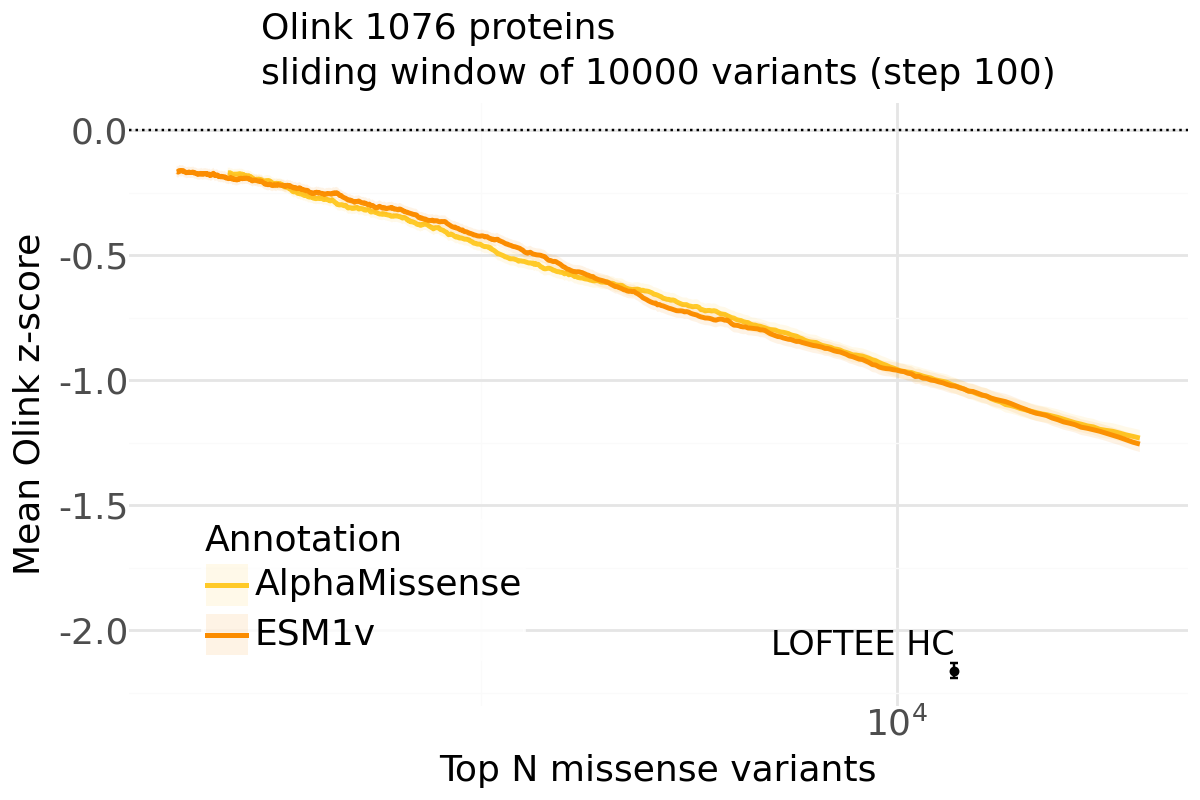

In [29]:
plot_df = (
    plt_df
    .filter(
        # (pl.col('annotation').is_in(['gpn_score', 'verphylop', 'promoterai', 'fz_all_mean']))
        (pl.col('annotation').is_in(['am_pathogenicity', 'esmscoremissense']))
    )
)

# Generate breaks and labels for x-axis (same style as odds ratio plot)
max_rank = zscore_binned['bin_center'].max()
min_rank = zscore_binned['bin_center'].min()
start_exp = int(np.floor(np.log10(1/max_rank)))
end_exp = int(np.ceil(np.log10(1/min_rank)))
breaks_linear = np.arange(start_exp, end_exp + 1)
labels_sci = [f"$10^{{{int(-b)}}}$" for b in breaks_linear]

color_dict = dict(zip(plt_df['label'], plt_df['color']))

(
    ggplot(
        plot_df,
        # aes(x='bin_id', y='mean_zscore')
        aes(x='log_bin_center_inv', y='mean_zscore')
    )
    + loftee_point
    + geom_hline(aes(yintercept=0), color='black', linetype='dotted')
    + geom_line(aes(color='label'), size=1)
    + geom_ribbon(aes(ymin='ci_lower', ymax='ci_upper', fill='label'), alpha=0.1)
    + scale_fill_manual(values=color_dict)
    + scale_color_manual(values=color_dict)
    + labs(
        title=f"Olink {olink_whitelist.shape[0]} proteins\nsliding window of {window_size} variants (step {step_size})",
        y=f"Mean Olink z-score",
        # x=f"Top N enhancer (pELS & dELS) variants",
        # x=f"Top N promoter (PLS & CA–H3K4me3) variants",
        x=f"Top N missense variants",
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_continuous(
        breaks=breaks_linear,
        labels=labels_sci
    )
    + theme_minimal()
    + theme(
        figure_size=(6, 4),
        title=element_text(size=13, lineheight=1.4),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        legend_position=(0.1, 0.1),
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)